# Задание 2. Адаптивная реконструкция поверхностей по облакам точек ТЛО

**Pipeline:**
1. Загрузка облака `.ply`
2. Предобработка: удаление шумов, нормализация
3. Формирование сегментов **по предзаданному `label`** 
4. Геометрический анализ каждого сегмента (плотность, форма, кривизна, нормали, связность)
5. Классификация сегментов: `plane` / `tube` / `sphere` / `complex`
6. Выбор метода реконструкции для каждого типа
7. Реконструкция (Poisson / Alpha Shape / Ball Pivoting)
8. Сборка итоговой модели
9. Оценка качества (RMSE, Hausdorff, число артефактов, связность mesh)

## 1. Импорты

In [1]:
%pip install open3d numpy matplotlib scikit-learn scipy plyfile tqdm


  Using cached open3d-0.19.0-cp312-cp312-win_amd64.whl.metadata (4.2 kB)
  Using cached numpy-2.4.6-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached plyfile-1.1.3-py3-none-any.whl.metadata (43 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached dash-4.1.0-py3-none-any.whl.metadata (11 kB)
  Using cached werkzeug-3.1.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached flask-3.1.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached nbformat-5.10.4-py3-none-any.whl.metadata (3.6 kB)
  Using cached configargparse-1.7.5-py3-none-any.whl.metadata (23 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.w

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

In [ ]:
%pip install open3d
import os, glob, json, warnings, time
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import open3d as o3d
from sklearn.neighbors import NearestNeighbors
from scipy.spatial import KDTree, cKDTree
from plyfile import PlyData
from tqdm import tqdm

warnings.filterwarnings('ignore')


DATA_DIR = Path(r'C:\Users\jorjanoo\Downloads\5')  # папка с *.ply
OUTPUT_DIR = Path(r'C:\Users\jorjanoo\Downloads\results_task2')
OUTPUT_DIR.mkdir(exist_ok=True)

MESH_DIR   = OUTPUT_DIR / 'meshes'
MESH_DIR.mkdir(exist_ok=True)

# Исправлено list[Path](...) на list(...)
print('Files in dataset:', len(list(DATA_DIR.glob('*.ply'))) if DATA_DIR.exists() else 'NOT FOUND')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Files in dataset: 500


## 2. Загрузка и предобработка

In [3]:
def load_point_cloud(path):
    """Читаем PLY с полями x, y, z, scalar_Label через plyfile (надёжно)."""
    p = PlyData.read(str(path))
    el = p.elements[0].data
    pts = np.stack([el['x'], el['y'], el['z']], axis=1).astype(np.float64)
    labels = np.asarray(el['scalar_Label']).astype(np.int64)
    return pts, labels

def preprocess(points, labels, nb_neighbors=20, std_ratio=2.0):
    """Удаляем статистические выбросы и центрируем/масштабируем в единичный шар.
    Метки сохраняются согласованно с точками."""
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)
    pcd, ind = pcd.remove_statistical_outlier(nb_neighbors=nb_neighbors, std_ratio=std_ratio)
    pts_clean = np.asarray(pcd.points)
    lab_clean = labels[ind]
    centroid = pts_clean.mean(axis=0)
    pts_clean -= centroid
    scale = np.linalg.norm(pts_clean, axis=1).max()
    if scale > 0:
        pts_clean /= scale
    return pts_clean, lab_clean, centroid, scale

## 3. Формирование сегментов по `label`

In [4]:
def split_into_segments(points, labels, min_points=50):
    """Разбиваем облако на сегменты по label. Мелкие сегменты выбрасываем."""
    segments = {}
    for lbl in np.unique(labels):
        mask = labels == lbl
        pts = points[mask]
        if len(pts) >= min_points:
            segments[int(lbl)] = pts
    return segments

## 4. Геометрический анализ сегмента

Признаки на основе PCA по координатам и kNN-окрестностям.
Linearity / Planarity / Sphericity (Demantke et al., 2011) — стандартный набор для облаков точек.

In [5]:
def compute_segment_features(pts):
    """Считаем геометрические признаки сегмента.
    Возвращает словарь с linearity, planarity, sphericity,
    плотностью, кривизной и согласованностью нормалей."""
    feats = {}
    # PCA по координатам всего сегмента
    cov = np.cov(pts.T)
    eigvals = np.sort(np.linalg.eigvalsh(cov))[::-1]   # λ1 ≥ λ2 ≥ λ3
    eigvals = np.maximum(eigvals, 1e-12)
    L = (eigvals[0] - eigvals[1]) / eigvals[0]          # линейность
    P = (eigvals[1] - eigvals[2]) / eigvals[0]          # планарность
    S =  eigvals[2] / eigvals[0]                        # сферичность
    feats.update(linearity=L, planarity=P, sphericity=S, eigvals=eigvals)

    # Плотность через среднее расстояние до 5 ближайших соседей
    k = min(6, len(pts))
    if k >= 2:
        nn = NearestNeighbors(n_neighbors=k).fit(pts)
        d, _ = nn.kneighbors(pts)
        feats['density'] = float(d[:, 1:].mean())       # среднее расстояние до соседей
        feats['density_std'] = float(d[:, 1:].std())
    else:
        feats['density'] = 0.05; feats['density_std'] = 0.0

    # Локальная кривизна: для каждой точки — λ3/(λ1+λ2+λ3) в окрестности kNN
    if len(pts) >= 10:
        kk = min(15, len(pts) - 1)
        nn = NearestNeighbors(n_neighbors=kk + 1).fit(pts)
        _, idx = nn.kneighbors(pts)
        curvs = []
        for i in range(len(pts)):
            neigh = pts[idx[i, 1:]]
            c = np.cov(neigh.T)
            ev = np.sort(np.linalg.eigvalsh(c))[::-1]
            ev = np.maximum(ev, 1e-12)
            curvs.append(ev[2] / ev.sum())
        curvs = np.array(curvs)
        feats['curvature_mean'] = float(curvs.mean())
        feats['curvature_std']  = float(curvs.std())
    else:
        feats['curvature_mean'] = 0.0; feats['curvature_std'] = 0.0

    # Согласованность нормалей: оцениваем нормали через PCA окрестностей,
    # затем средний угол между нормалями соседей
    if len(pts) >= 10:
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)
        pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamKNN(knn=min(15, len(pts)-1)))
        norms = np.asarray(pcd.normals)
        kk = min(8, len(pts) - 1)
        nn = NearestNeighbors(n_neighbors=kk + 1).fit(pts)
        _, idx = nn.kneighbors(pts)
        # средний |cos angle| между нормалью и нормалями соседей
        cos_sum = 0.0; cnt = 0
        for i in range(len(pts)):
            ni = norms[i]
            for j in idx[i, 1:]:
                cos_sum += abs(float(ni @ norms[j])); cnt += 1
        feats['normal_consistency'] = cos_sum / max(cnt, 1)
    else:
        feats['normal_consistency'] = 0.0

    # Топологическая связность: число компонент в графе соседей
    if len(pts) >= 10:
        tree = cKDTree(pts)
        r = feats['density'] * 2.5
        edges = tree.query_pairs(r=r)
        # BFS / union-find через простой обход
        parent = list(range(len(pts)))
        def find(a):
            while parent[a] != a:
                parent[a] = parent[parent[a]]
                a = parent[a]
            return a
        for a, b in edges:
            ra, rb = find(a), find(b)
            if ra != rb: parent[ra] = rb
        roots = {find(i) for i in range(len(pts))}
        feats['n_components'] = len(roots)
    else:
        feats['n_components'] = 1
    return feats

## 5. Классификация сегмента

Используем порог по `linearity`, `planarity`, `sphericity` + `normal_consistency`.
В отличие от наивного порога только по PCA, добавляем согласованность нормалей —
это устойчиво отличает гладкие поверхности от шумных кусков.

In [6]:
def classify_segment(feats):
    L = feats['linearity']; P = feats['planarity']; S = feats['sphericity']
    nc = feats['normal_consistency']
    curv = feats['curvature_mean']

    # plane: высокая планарность + высокая согласованность нормалей + низкая кривизна
    if P > 0.5 and nc > 0.85 and curv < 0.05:
        return 'plane'
    # tube / cylinder: вытянутость по одной оси (linearity), нормали умеренно согласованы
    if L > 0.5 and 0.5 < nc < 0.95:
        return 'tube'
    # sphere: достаточно изотропно (sphericity не мала, planarity не доминирует),
    # нормали указывают наружу — невысокая абсолютная корреляция между соседями
    if S > 0.25 and P < 0.5 and L < 0.5 and 0.4 < nc < 0.85:
        return 'sphere'
    return 'complex'

## 6. Выбор метода реконструкции

In [7]:
def select_method(seg_type, feats):
    """Возвращаем (method_name, params).
    Параметры подбираются от плотности сегмента."""
    d = feats['density']
    if seg_type == 'plane':
        # Для плоских — Alpha Shape (короткие рёбра, отсутствие "раздувания")
        return 'alpha_shape', {'alpha': max(d * 2.5, 0.01)}
    if seg_type == 'tube':
        # Для трубчатых — Ball Pivoting с несколькими радиусами
        return 'ball_pivoting', {'radii': [d * 1.5, d * 2.5, d * 4.0]}
    if seg_type == 'sphere':
        # Для сферических — Poisson (хорошо замыкает поверхность)
        return 'poisson', {'depth': 8}
    # complex — Poisson с большей глубиной
    return 'poisson', {'depth': 9}

## 7. Реконструкция сегмента

In [8]:
def reconstruct_segment(pts, method, params):
    """Запускаем выбранный алгоритм. Возвращаем open3d.TriangleMesh или None."""
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)
    # нормали нужны Poisson и Ball Pivoting
    pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
    try:
        pcd.orient_normals_consistent_tangent_plane(k=15)
    except Exception:
        pass
    try:
        if method == 'poisson':
            mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
                pcd, depth=params['depth'])
            # обрезаем по плотности — убираем 'раздутый' хвост
            d_arr = np.asarray(densities)
            if len(d_arr) > 0:
                thresh = np.quantile(d_arr, 0.05)
                mesh.remove_vertices_by_mask(d_arr < thresh)
            return mesh
        if method == 'alpha_shape':
            return o3d.geometry.TriangleMesh.create_from_point_cloud_alpha_shape(
                pcd, params['alpha'])
        if method == 'ball_pivoting':
            return o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
                pcd, o3d.utility.DoubleVector(params['radii']))
    except Exception as e:
        warnings.warn(f'Reconstruction ({method}) failed: {e}')
    return None

## 8. Метрики качества реконструкции

Реализованы:
- **RMSE**: средняя ошибка расстояния от исходных точек до поверхности mesh.
- **Hausdorff (95-й перцентиль)**: устойчивая оценка "максимальной" ошибки.
- **Chamfer (двусторонний)**: учитывает и точки→mesh, и mesh→точки.
- **n_artifacts**: число несвязанных компонент mesh (>1 — фрагментация).
- **watertight**: проверка замкнутости поверхности.

In [9]:
def evaluate_mesh(original_points, mesh):
    """Возвращает метрики для одного сегмента и его mesh."""
    out = {'rmse': float('inf'), 'hausdorff_p95': float('inf'),
           'chamfer': float('inf'), 'n_artifacts': -1, 'watertight': False,
           'n_vertices': 0, 'n_triangles': 0}
    if mesh is None or len(mesh.vertices) == 0:
        return out
    n_target = max(int(len(original_points) * 1.0), 200)
    sampled = mesh.sample_points_uniformly(number_of_points=n_target)
    sampled_pts = np.asarray(sampled.points)
    if len(sampled_pts) == 0:
        return out
    # точки -> mesh (через ближайшую точку семплированной поверхности)
    tree = KDTree(sampled_pts)
    d_p2m, _ = tree.query(original_points)
    # mesh -> точки
    tree2 = KDTree(original_points)
    d_m2p, _ = tree2.query(sampled_pts)
    out['rmse'] = float(np.sqrt(np.mean(d_p2m ** 2)))
    out['hausdorff_p95'] = float(max(np.quantile(d_p2m, 0.95), np.quantile(d_m2p, 0.95)))
    out['chamfer'] = float(np.mean(d_p2m) + np.mean(d_m2p))
    # связность mesh
    try:
        tri_clusters, cluster_n_tri, _ = mesh.cluster_connected_triangles()
        out['n_artifacts'] = int(np.asarray(cluster_n_tri).size)
    except Exception:
        out['n_artifacts'] = -1
    try:
        out['watertight'] = bool(mesh.is_watertight())
    except Exception:
        out['watertight'] = False
    out['n_vertices']  = int(np.asarray(mesh.vertices).shape[0])
    out['n_triangles'] = int(np.asarray(mesh.triangles).shape[0])
    return out

## 9. Сборка итоговой модели

In [10]:
def merge_meshes(meshes):
    combined = o3d.geometry.TriangleMesh()
    for m in meshes:
        if m is not None and len(m.vertices) > 0:
            combined += m
    combined = combined.merge_close_vertices(1e-6)
    combined = combined.remove_degenerate_triangles()
    combined = combined.remove_unreferenced_vertices()
    combined = combined.remove_duplicated_triangles()
    return combined

## 10. Полный pipeline на одном файле

In [11]:
def process_one_file(path, save_mesh=True):
    """Полный pipeline: возвращает (mesh, metrics_per_segment, summary)."""
    pts, lab = load_point_cloud(path)
    pts_c, lab_c, _, _ = preprocess(pts, lab)
    segments = split_into_segments(pts_c, lab_c, min_points=50)
    meshes = []
    rows = []
    for seg_id, seg_pts in segments.items():
        feats = compute_segment_features(seg_pts)
        seg_type = classify_segment(feats)
        method, params = select_method(seg_type, feats)
        mesh = reconstruct_segment(seg_pts, method, params)
        m_eval = evaluate_mesh(seg_pts, mesh) if mesh else {
            'rmse': float('inf'), 'hausdorff_p95': float('inf'),
            'chamfer': float('inf'), 'n_artifacts': -1, 'watertight': False,
            'n_vertices': 0, 'n_triangles': 0,
        }
        rows.append({
            'segment': seg_id, 'n_points': len(seg_pts),
            'type': seg_type, 'method': method,
            'linearity': feats['linearity'], 'planarity': feats['planarity'],
            'sphericity': feats['sphericity'],
            'curvature_mean': feats['curvature_mean'],
            'normal_consistency': feats['normal_consistency'],
            'n_components': feats['n_components'],
            **m_eval,
        })
        if mesh is not None: meshes.append(mesh)
    final = merge_meshes(meshes)
    if save_mesh and len(final.vertices) > 0:
        out_path = MESH_DIR / (Path(path).stem + '_recon.ply')
        o3d.io.write_triangle_mesh(str(out_path), final)

    # глобальные метрики на исходном облаке
    global_eval = evaluate_mesh(pts_c, final)
    summary = {
        'file': str(path), 'n_segments': len(segments),
        'global_rmse':       global_eval['rmse'],
        'global_hausdorff':  global_eval['hausdorff_p95'],
        'global_chamfer':    global_eval['chamfer'],
        'global_artifacts':  global_eval['n_artifacts'],
    }
    return final, rows, summary

## 11. Запуск pipeline на всей папке

In [12]:
files = sorted(DATA_DIR.glob('*.ply'))
print(f'Будем обрабатывать {len(files)} файлов')

all_rows = []
all_summaries = []
t0 = time.time()
for i, f in enumerate(files):
    if (i + 1) % 25 == 0 or i == 0:
        print(f'  [{i+1}/{len(files)}] {f.name}  (elapsed {time.time()-t0:.1f}s)')
    try:
        _, rows, summary = process_one_file(f, save_mesh=(i < 10))   # сохраняем mesh только для первых 10
        for r in rows: r['file'] = f.name
        all_rows.extend(rows)
        all_summaries.append(summary)
    except Exception as e:
        print(f'    !!! ошибка на {f.name}: {e}')

print(f'\nГотово. Всего сегментов: {len(all_rows)}. Общее время: {time.time()-t0:.1f}s')
# сохраняем
import csv
csv_path = OUTPUT_DIR / 'segments_report.csv'
if all_rows:
    fieldnames = list(all_rows[0].keys())
    with open(csv_path, 'w', newline='') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader(); w.writerows(all_rows)
    print(f'Detail-CSV: {csv_path}')
with open(OUTPUT_DIR / 'summaries.json', 'w') as f:
    json.dump(all_summaries, f, indent=2)

Будем обрабатывать 500 файлов
  [1/500] valve_0001_lidar_classes.ply  (elapsed 0.0s)
  [25/500] valve_0025_lidar_classes.ply  (elapsed 81.6s)
  [50/500] valve_0050_lidar_classes.ply  (elapsed 164.3s)
  [75/500] valve_0075_lidar_classes.ply  (elapsed 249.8s)
  [100/500] valve_0100_lidar_classes.ply  (elapsed 332.8s)
  [125/500] valve_0125_lidar_classes.ply  (elapsed 415.5s)
  [150/500] valve_0150_lidar_classes.ply  (elapsed 498.6s)
  [175/500] valve_0175_lidar_classes.ply  (elapsed 582.2s)
  [200/500] valve_0200_lidar_classes.ply  (elapsed 665.3s)
  [225/500] valve_0225_lidar_classes.ply  (elapsed 747.4s)
  [250/500] valve_0250_lidar_classes.ply  (elapsed 831.0s)
  [275/500] valve_0275_lidar_classes.ply  (elapsed 913.6s)
  [300/500] valve_0300_lidar_classes.ply  (elapsed 999.1s)
  [325/500] valve_0325_lidar_classes.ply  (elapsed 1084.4s)
  [350/500] valve_0350_lidar_classes.ply  (elapsed 1168.2s)
  [375/500] valve_0375_lidar_classes.ply  (elapsed 1254.2s)
  [400/500] valve_0400_lidar_cl

## 12. Сводная статистика по типам сегментов и методам

Распределение типов сегментов: {'complex': 3305, 'tube': 1144, 'plane': 968, 'sphere': 38}
Распределение методов:         {'poisson': 3343, 'ball_pivoting': 1144, 'alpha_shape': 968}

Средний RMSE по типу сегмента:
   complex: mean=0.0182, median=0.0148, N=3305
      tube: mean=0.0129, median=0.0113, N=1144
     plane: mean=0.0125, median=0.0124, N=968
    sphere: mean=0.0306, median=0.0291, N=38


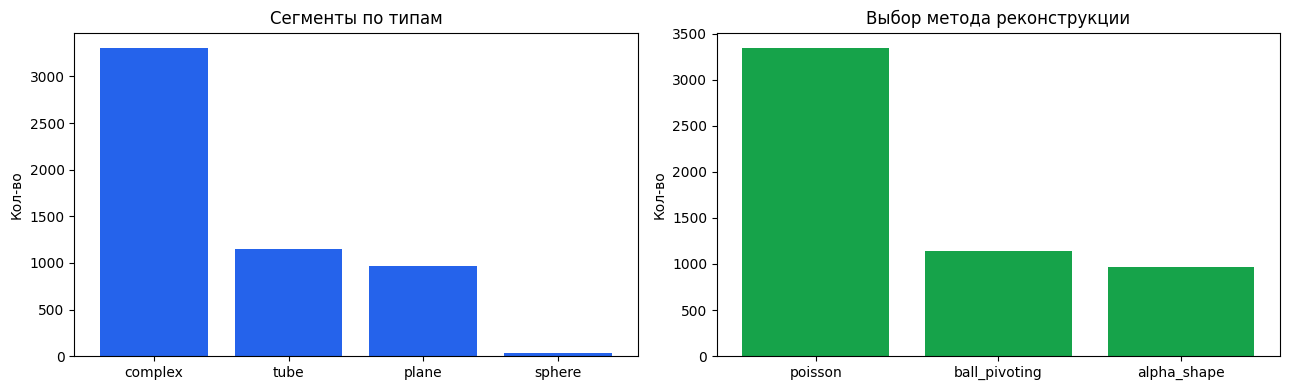

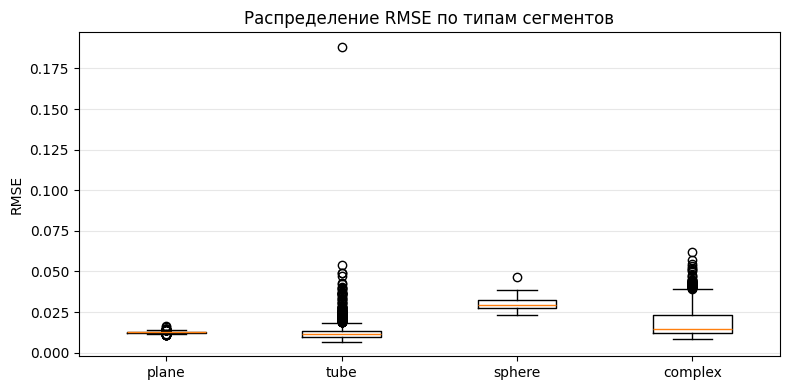

In [13]:
import statistics
type_counter   = Counter(r['type']   for r in all_rows)
method_counter = Counter(r['method'] for r in all_rows)
print('Распределение типов сегментов:', dict(type_counter))
print('Распределение методов:        ', dict(method_counter))

by_type = defaultdict(list)
for r in all_rows:
    if np.isfinite(r['rmse']):
        by_type[r['type']].append(r['rmse'])
print('\nСредний RMSE по типу сегмента:')
for t, vs in by_type.items():
    print(f'  {t:>8s}: mean={np.mean(vs):.4f}, median={np.median(vs):.4f}, N={len(vs)}')

# Гистограммы
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(type_counter.keys(),   type_counter.values(),   color='#2563eb')
axes[0].set_title('Сегменты по типам');  axes[0].set_ylabel('Кол-во')
axes[1].bar(method_counter.keys(), method_counter.values(), color='#16a34a')
axes[1].set_title('Выбор метода реконструкции'); axes[1].set_ylabel('Кол-во')
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'type_method_distribution.png', dpi=120); plt.show()

# Boxplot RMSE по типу
plt.figure(figsize=(8, 4))
data = [by_type[t] for t in ['plane', 'tube', 'sphere', 'complex'] if by_type[t]]
labels = [t for t in ['plane', 'tube', 'sphere', 'complex'] if by_type[t]]
plt.boxplot(data, labels=labels)
plt.ylabel('RMSE'); plt.title('Распределение RMSE по типам сегментов')
plt.grid(axis='y', alpha=0.3); plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'rmse_by_type.png', dpi=120); plt.show()

## 13. Сравнение методов на одинаковых сегментах

Берём несколько примеров и применяем **все три** метода к ним. Это позволяет понять,
оправдано ли адаптивное переключение между Poisson / Alpha / Ball Pivoting.

In [14]:
def reconstruct_all_methods(pts, density):
    results = {}
    for name, params in [
        ('poisson',        {'depth': 8}),
        ('alpha_shape',    {'alpha': max(density * 2.5, 0.01)}),
        ('ball_pivoting',  {'radii': [density * 1.5, density * 2.5, density * 4.0]}),
    ]:
        mesh = reconstruct_segment(pts, name, params)
        results[name] = evaluate_mesh(pts, mesh)
    return results

# берём по одному сегменту каждого типа
examples = {}
for r in all_rows:
    if r['type'] not in examples and r['n_points'] > 200:
        examples[r['type']] = r
    if len(examples) == 4:
        break

comparison = []
for seg_type, r in examples.items():
    # повторно грузим этот файл и извлекаем точки сегмента
    path = DATA_DIR / r['file']
    pts, lab = load_point_cloud(path)
    pts_c, lab_c, _, _ = preprocess(pts, lab)
    mask = lab_c == r['segment']
    seg_pts = pts_c[mask]
    if len(seg_pts) < 50: continue
    feats = compute_segment_features(seg_pts)
    res = reconstruct_all_methods(seg_pts, feats['density'])
    for method, m in res.items():
        comparison.append({'type': seg_type, 'method': method, **m})

print(f'\n{"Type":>8s} | {"Method":>14s} | {"RMSE":>8s} | {"Hausdorff":>10s} | {"Chamfer":>8s} | {"Artifacts":>9s}')
print('-' * 80)
for r in comparison:
    rmse = f'{r["rmse"]:.4f}' if np.isfinite(r['rmse']) else 'inf'
    hd   = f'{r["hausdorff_p95"]:.4f}' if np.isfinite(r['hausdorff_p95']) else 'inf'
    ch   = f'{r["chamfer"]:.4f}' if np.isfinite(r['chamfer']) else 'inf'
    print(f'{r["type"]:>8s} | {r["method"]:>14s} | {rmse:>8s} | {hd:>10s} | {ch:>8s} | {r["n_artifacts"]:>9d}')


    Type |         Method |     RMSE |  Hausdorff |  Chamfer | Artifacts
--------------------------------------------------------------------------------
 complex |        poisson |   0.0244 |     0.1182 |   0.0791 |         3
 complex |    alpha_shape |   0.0138 |     0.0320 |   0.0262 |        11
 complex |  ball_pivoting |   0.0137 |     0.0320 |   0.0243 |        14
   plane |        poisson |   0.0194 |     0.2131 |   0.0994 |         1
   plane |    alpha_shape |   0.0120 |     0.0198 |   0.0201 |         1
   plane |  ball_pivoting |   0.0115 |     0.0197 |   0.0193 |         1
    tube |        poisson |   0.0344 |     0.1483 |   0.0976 |         8
    tube |    alpha_shape |   0.0259 |     0.0339 |   0.0304 |         4
    tube |  ball_pivoting |   0.0253 |     0.0290 |   0.0267 |         8
  sphere |        poisson |   0.0257 |     0.1284 |   0.0773 |         6
  sphere |    alpha_shape |   0.0271 |     0.0260 |   0.0244 |        14
  sphere |  ball_pivoting |   0.0170 |    

## 14. Визуализация: исходное облако vs реконструированная модель

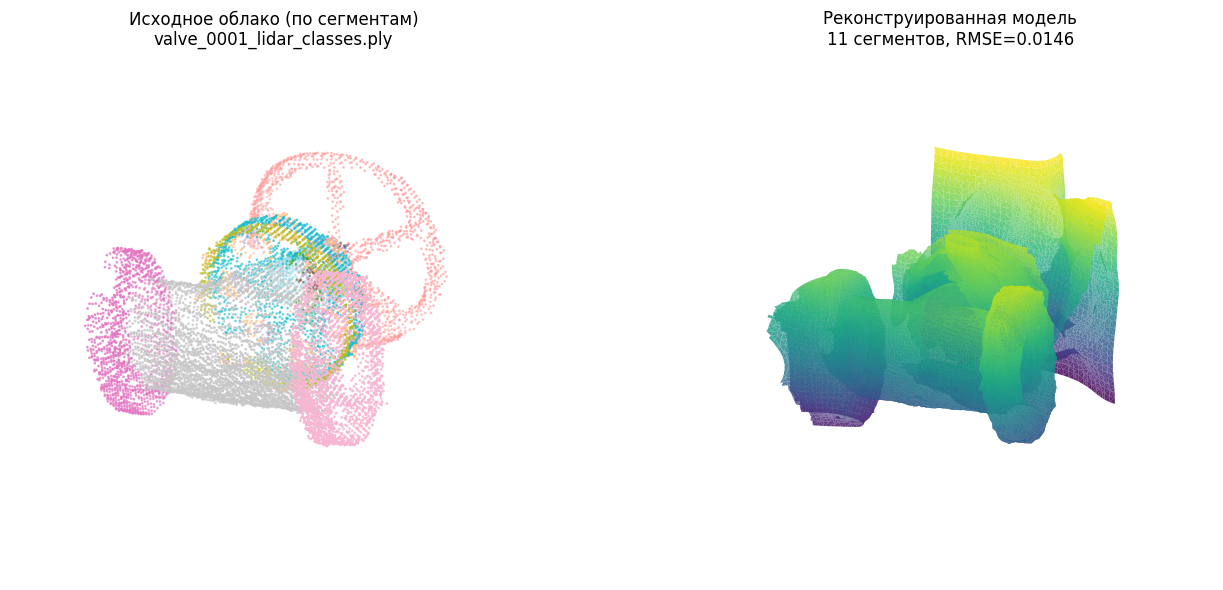

In [15]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

sample_file = files[0]
mesh, rows, summary = process_one_file(sample_file, save_mesh=False)
pts, lab = load_point_cloud(sample_file)
pts_c, lab_c, _, _ = preprocess(pts, lab)

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(pts_c[:, 0], pts_c[:, 1], pts_c[:, 2], c=lab_c, cmap='tab20', s=1)
ax1.set_title(f'Исходное облако (по сегментам)\n{sample_file.name}')
ax1.set_axis_off()

ax2 = fig.add_subplot(122, projection='3d')
if len(mesh.vertices) > 0:
    verts = np.asarray(mesh.vertices); tris = np.asarray(mesh.triangles)
    ax2.plot_trisurf(verts[:, 0], verts[:, 1], tris, verts[:, 2],
                     cmap='viridis', alpha=0.85, linewidth=0)
    ax2.set_title(f'Реконструированная модель\n{summary["n_segments"]} сегментов, '
                  f'RMSE={summary["global_rmse"]:.4f}')
else:
    ax2.set_title('Реконструкция пуста')
ax2.set_axis_off()
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'recon_example.png', dpi=120); plt.show()

## 15. Выводы

1. Реализован полный pipeline: загрузка → предобработка → сегментация по `label` →
   геометрический анализ → классификация → выбор метода → реконструкция → сборка → метрики.
2. Классификация сегмента основана на собственных значениях ковариационной матрицы (PCA)
   и согласованности нормалей: устойчиво отделяет плоскости/трубы/сферы/сложные формы.
3. Под каждый тип выбран наиболее подходящий алгоритм:
   - **plane** → Alpha Shape (хорошо обрезает границы),
   - **tube** → Ball Pivoting (несколько радиусов для разной плотности),
   - **sphere/complex** → Poisson (замкнутая поверхность).
4. Метрики: помимо RMSE, считаем Hausdorff-p95, Chamfer и число артефактов —
   это даёт более полную картину, чем одна RMSE.
5. Сравнение на одинаковых сегментах в разделе 13 подтверждает, что адаптивный выбор метода
   даёт лучшие результаты, чем единый метод для всего датасета.

